# Consumption data explorative analysis

## Overview

In [66]:
# to read datafile
import pandas as pd

# to use SQL queries
import duckdb as db

# to make simple charts
import matplotlib.pyplot as plt

In [67]:
# reads datafile in from another folder
consumption_df = pd.read_csv('../../DataSources/real_electricity_consumption_sorted.csv', sep = ",")
consumption_df

,household_id,timestamp,date,time,consumption_kwh
0,s-1,01.04.2025 00:00:00,01.04.2025,00:00:00,0.026
1,s-1,01.04.2025 00:15:00,01.04.2025,00:15:00,0.063
2,s-1,01.04.2025 00:30:00,01.04.2025,00:30:00,0.021
3,s-1,01.04.2025 00:45:00,01.04.2025,00:45:00,0.028
4,s-1,01.04.2025 01:00:00,01.04.2025,01:00:00,0.013
...,...,...,...,...,...
1264603,xl-10,28.02.2026 22:45:00,28.02.2026,22:45:00,5.487
1264604,xl-10,28.02.2026 23:00:00,28.02.2026,23:00:00,0.798
1264605,xl-10,28.02.2026 23:15:00,28.02.2026,23:15:00,5.474
1264606,xl-10,28.02.2026 23:30:00,28.02.2026,23:30:00,5.366


In [68]:
# overview of datafile values
db.sql("SUMMARIZE SELECT * FROM consumption_df")

┌─────────────────┬─────────────┬─────────────────────┬─────────────────────┬───────────────┬────────────────────┬────────────────────┬─────────────────────┬─────────────────────┬─────────────────────┬─────────┬─────────────────┐
│   column_name   │ column_type │         min         │         max         │ approx_unique │        avg         │        std         │         q25         │         q50         │         q75         │  count  │ null_percentage │
│     varchar     │   varchar   │       varchar       │       varchar       │     int64     │      varchar       │      varchar       │       varchar       │       varchar       │       varchar       │  int64  │  decimal(9,2)   │
├─────────────────┼─────────────┼─────────────────────┼─────────────────────┼───────────────┼────────────────────┼────────────────────┼─────────────────────┼─────────────────────┼─────────────────────┼─────────┼─────────────────┤
│ household_id    │ VARCHAR     │ l-1                 │ xl-9                │   

In [69]:
# changes timestamp from str to datetime
consumption_df['timestamp'] = pd.to_datetime(consumption_df['timestamp'], format='%d.%m.%Y %H:%M:%S')

# changes date from str to datetime
consumption_df['date'] = pd.to_datetime(consumption_df['date'], format='%d.%m.%Y')

# changes time from str to datetime
consumption_df['time'] = pd.to_datetime(consumption_df['time'], format='%H:%M:%S')

# changes consumption from str to float with decimal separator normalization
consumption_df['consumption_kwh'] = consumption_df['consumption_kwh'].astype(float)


In [70]:
# counts & names unique id-s
print(consumption_df['household_id'].unique())

<ArrowStringArray>
[  's-1',   's-2',   's-3',   's-4',   's-5',   's-6',   's-7',   's-8',
   's-9',  's-10',   'l-1',   'l-2',   'l-3',   'l-4',   'l-5',   'l-6',
   'l-7',   'l-8',   'l-9',  'l-10',   'm-1',   'm-2',   'm-3',   'm-4',
   'm-5',   'm-6',   'm-7',   'm-8',   'm-9',  'm-10',  'xl-1',  'xl-2',
  'xl-3',  'xl-4',  'xl-5',  'xl-6',  'xl-7',  'xl-8',  'xl-9', 'xl-10']
Length: 40, dtype: str


In [71]:
# split into two columns
consumption_df[['size', 'num']] = consumption_df['household_id'].str.split('-', expand=True)

# define correct order for size
size_order = {'s': 0, 'm': 1, 'l': 2, 'xl': 3}
consumption_df['size_order'] = consumption_df['size'].map(size_order)

# convert number part to integer
consumption_df['num'] = consumption_df['num'].astype(int)

# sort
consumption_df = consumption_df.sort_values(['size_order', 'num'])

# (optional) drop helper columns
consumption_df = consumption_df.drop(columns=['size', 'num', 'size_order'])

In [72]:
# extracts day-of-week from date column
consumption_df['dayofweek'] = consumption_df['date'].dt.dayofweek

# extracts hour from time column
consumption_df['hour'] = consumption_df['time'].dt.hour

In [73]:
# checks column datatypes
consumption_df.dtypes

household_id                  str
timestamp          datetime64[us]
date               datetime64[us]
time               datetime64[us]
consumption_kwh           float64
dayofweek                   int32
hour                        int32
dtype: object

In [74]:
print(consumption_df)

        household_id           timestamp       date                time  \
0                s-1 2025-04-01 00:00:00 2025-04-01 1900-01-01 00:00:00   
1                s-1 2025-04-01 00:15:00 2025-04-01 1900-01-01 00:15:00   
2                s-1 2025-04-01 00:30:00 2025-04-01 1900-01-01 00:30:00   
3                s-1 2025-04-01 00:45:00 2025-04-01 1900-01-01 00:45:00   
4                s-1 2025-04-01 01:00:00 2025-04-01 1900-01-01 01:00:00   
...              ...                 ...        ...                 ...   
1264603        xl-10 2026-02-28 22:45:00 2026-02-28 1900-01-01 22:45:00   
1264604        xl-10 2026-02-28 23:00:00 2026-02-28 1900-01-01 23:00:00   
1264605        xl-10 2026-02-28 23:15:00 2026-02-28 1900-01-01 23:15:00   
1264606        xl-10 2026-02-28 23:30:00 2026-02-28 1900-01-01 23:30:00   
1264607        xl-10 2026-02-28 23:45:00 2026-02-28 1900-01-01 23:45:00   

         consumption_kwh  dayofweek  hour  
0                  0.026          1     0  
1          

## Data aggregation

In [75]:
# aggregates consumption by year
consumption_per_year = db.query("""
    SELECT
        YEAR(date) AS year,
        SUM(consumption_kwh) AS total_consumption_kwh
    FROM consumption_df
    GROUP BY YEAR(date)
    ORDER BY year
""").df()

print(consumption_per_year)

   year  total_consumption_kwh
0  2025             231708.777
1  2026             129245.753


In [76]:
# aggregates consumption by month
consumption_per_month = db.query("""
    SELECT
        month(date) AS month,
        SUM(consumption_kwh) AS total_consumption_kwh
    FROM consumption_df
    GROUP BY month(date)
    ORDER BY month
""").df()

print(consumption_per_month)

    month  total_consumption_kwh
0       1              70704.162
1       2              58541.591
2       4              21721.854
3       5              17561.169
4       6              15609.433
5       7              14526.602
6       8              16163.047
7       9              18259.661
8      10              33129.568
9      11              43428.589
10     12              51308.854


In [77]:
# aggregates consumption by day
consumption_per_day = db.query("""
    SELECT
        day(date) AS day,
        SUM(consumption_kwh) AS total_consumption_kwh
    FROM consumption_df
    GROUP BY day(date)
    ORDER BY day
""").df()

print(consumption_per_day)

    day  total_consumption_kwh
0     1              12435.053
1     2              11281.060
2     3              10958.114
3     4              11241.615
4     5              12059.585
5     6              11951.114
6     7              11587.772
7     8              11912.719
8     9              11512.198
9    10              11743.303
10   11              11658.479
11   12              11711.736
12   13              11565.683
13   14              11843.883
14   15              12330.554
15   16              11385.920
16   17              11670.311
17   18              11507.866
18   19              11713.963
19   20              11987.337
20   21              11765.130
21   22              11557.461
22   23              12518.621
23   24              12592.549
24   25              12862.687
25   26              12017.800
26   27              12103.818
27   28              12005.362
28   29              10551.209
29   30              11138.670
30   31               7782.958


In [78]:
# aggregates consumption by hour
consumption_per_hour = db.query("""
    SELECT
        hour(time) AS hour,
        SUM(consumption_kwh) AS total_consumption_kwh
    FROM consumption_df
    GROUP BY hour(time)
    ORDER BY hour
""").df()

print(consumption_per_hour)

    hour  total_consumption_kwh
0      0              22832.981
1      1              21224.687
2      2              22039.553
3      3              22937.447
4      4              23055.601
5      5              19031.453
6      6              15321.671
7      7              13360.761
8      8              11498.103
9      9              10213.488
10    10               9791.224
11    11               9989.971
12    12              10503.926
13    13              10367.676
14    14              10976.993
15    15              11528.476
16    16              11619.734
17    17              12705.943
18    18              13434.004
19    19              13872.758
20    20              14557.835
21    21              14960.063
22    22              16411.453
23    23              18718.729


In [79]:
# aggregates consumption by household_id
consumption_per_household = db.query("""
    SELECT
        household_id AS household,
        SUM(consumption_kwh) AS total_consumption_kwh
    FROM consumption_df
    GROUP BY household
    ORDER BY total_consumption_kwh ASC
""").df()

print(consumption_per_household)

   household  total_consumption_kwh
0        s-3                 82.916
1        s-2               1904.682
2        s-9               2120.120
3       s-10               2530.743
4        s-5               2640.648
5        m-2               2874.027
6        s-8               2925.004
7        s-7               3075.158
8        s-1               3553.223
9        m-5               3630.814
10       m-1               4741.037
11       m-6               5189.547
12      m-10               5395.505
13       m-4               5491.583
14       m-7               5627.753
15       s-6               6496.716
16       l-4               6665.676
17       l-3               6665.676
18       m-8               6774.565
19       l-6               6779.577
20       m-9               8096.422
21       l-7               8507.139
22       l-8               8825.706
23       l-2               9750.865
24       m-3              10266.239
25       l-5              10367.667
26       l-1              10

In [80]:
# aggregates consumption by client segment
consumption_per_segment = db.query("""
    SELECT
        UPPER(SPLIT_PART(household_id, '-', 1)) AS client_segment,
        SUM(consumption_kwh) AS total_consumption_kwh
    FROM consumption_df
    GROUP BY client_segment
    ORDER BY total_consumption_kwh ASC
""").df()

print(consumption_per_segment)

  client_segment  total_consumption_kwh
0              S              39519.169
1              M              58087.492
2              L              89814.599
3             XL             173533.270


In [ ]:
# aggregates consumption per segment in a month
monthly_segments = db.query("""
    SELECT
        TRIM(strftime(date, '%B')) AS month,
        EXTRACT(MONTH FROM date) AS month_num,
        UPPER(SPLIT_PART(household_id, '-', 1)) AS client_segment,
        SUM(consumption_kwh) AS total_consumption_kwh
    FROM consumption_df
    GROUP BY month, month_num, client_segment
    ORDER BY month_num, client_segment
""").df()

print(monthly_segments)

In [109]:
consumption_stats = db.query("""
    SELECT 
        household_id,
        UPPER(SPLIT_PART(household_id, '-', 1)) AS client_segment,
        COUNT(*) as total_kwh,
        SUM(consumption_kwh) as annual_consumption,
        AVG(consumption_kwh) as avg_consumption,
        MAX(consumption_kwh) as peak_consumption,
        MIN(consumption_kwh) as min_consumption,
        STDDEV(consumption_kwh) as consumption_volatility
    FROM consumption_df
    GROUP BY household_id, client_segment""").df()

## Simple graphs

In [ ]:
# consumption by year graph, converting year into a discrete category / matplot
ax = consumption_per_year.assign(year=consumption_per_year['year'].astype(str)).plot(
    x="year", y="total_consumption_kwh", kind="line"
)

# defines the amount of x axis points
ax.set_xticks([0, 1])

# defines the labels on x axis points
ax.set_xticklabels(['2025', '2026'])

# defines the y axis starting point as 0
ax.set_ylim(0, None)

# adds a title to the graph
ax.set_title("Total consumption by year", fontsize=13)

# adds a title to y axis
ax.set_ylabel("Total consumption (kWh)")

In [ ]:
# consumption by month graph / matplot
ax = consumption_per_month.plot(
    x="month", y="total_consumption_kwh", kind="line")

# defines the amount of x axis points
ax.set_xticks(range(12))

# defines the labels on x axis points
ax.set_xticklabels(range(1, 13))

# defines the y axis starting point as 0
ax.set_ylim(0, None)

# defines seasons / st-ni
spring_start = 2
spring_end = 5
summer_start = 5
summer_end = 8
autumn_start = 8
autumn_end = 11
winter_start = 11
winter_end = 2

# adds a light color for spring
ax.axvspan(spring_start, spring_end, alpha=0.2, color='green', label='Spring')

# adds a light color for summer
ax.axvspan(summer_start, summer_end, alpha=0.2, color='yellow', label='Summer')

# adds a light color for autumn
ax.axvspan(autumn_start, autumn_end, alpha=0.2, color='brown', label='Autumn')

# adds a light color for winter
ax.axvspan(winter_start, 12, alpha=0.2, color='blue', label = 'Winter')
ax.axvspan(0, winter_end, alpha=0.2, color='blue')

# adds a legend
ax.legend()

# adds a title to the graph
ax.set_title("Total consumption by month", fontsize=13)

# adds a title to y axis
ax.set_ylabel("Total consumption (kWh)")


In [ ]:
# consumption by day graph / matplot
ax = consumption_per_day.plot(
    x="day", y="total_consumption_kwh", kind="line", figsize=[12,5])

# defines the amount of x axis points
ax.set_xticks(range(31))

# defines the labels on x axis points
ax.set_xticklabels(range(1, 32))

# defines the y axis starting point as 0
ax.set_ylim(0, None)

# adds a title to the graph
ax.set_title("Total consumption by day", fontsize=13)

# adds a title to y axis
ax.set_ylabel("Total consumption (kWh)")

In [ ]:
# consumption by hour graph / matplot
ax = consumption_per_hour.plot(
    x="hour", y="total_consumption_kwh", kind="line", figsize=[10,5])

# defines the amount of x axis points
ax.set_xticks(range(24))

# defines the labels on x axis points
ax.set_xticklabels(range(0, 24))

# defines the y axis starting point as 0
ax.set_ylim(0, None)

# defines daytime and nighttime
day_start = 7
night_start = 22

# adds a light color for daytime
ax.axvspan(day_start, night_start, alpha=0.05, color='yellow', label='Daytime')

# adds a light color for nighttime
ax.axvspan(0, day_start, alpha=0.05, color='blue', label='Nighttime')
ax.axvspan(night_start, 23, alpha=0.05, color='blue')

# defines peak hours
morning_peak_start = 7
morning_peak_end = 9
evening_peak_start = 17
evening_peak_end = 20

# adds a light color for peak times in the morning and evening
ax.axvspan(morning_peak_start, morning_peak_end, alpha=0.2, color='red', label='Peak')
ax.axvspan(evening_peak_start, evening_peak_end, alpha=0.2, color='red')

# adds a legend
ax.legend()

# adds a title to the graph
ax.set_title("Total consumption by hour", fontsize=13)

# adds a title to y axis
ax.set_ylabel("Total consumption (kWh)")

In [ ]:
# consumption by household bar chart / matplot
ax = consumption_per_household.plot(
    x="household", y="total_consumption_kwh", kind="bar", figsize=(20, 5))

# defines the y axis starting point as 0
ax.set_ylim(0, None)

# sets x axis points straight
ax.tick_params(axis='x', labelrotation=0)

# counts the x axis points
len(ax.get_xticks())

# adds a title to the graph
ax.set_title("Total consumption by household", fontsize=13)

# adds a title to y axis
ax.set_ylabel("Total consumption (kWh)")

In [ ]:
# consumption by household bar chart / matplot
ax = consumption_per_segment.plot(
    x="client_segment", y="total_consumption_kwh", kind="bar", figsize=(15, 5))

# defines the y axis starting point as 0
ax.set_ylim(0, None)

# counts the x axis points
len(ax.get_xticks())

# sets x axis points straight
ax.tick_params(axis='x', labelrotation=0)

# adds a title to the graph
ax.set_title("Total consumption by household", fontsize=13)

# adds a title to y axis
ax.set_ylabel("Total consumption (kWh)")

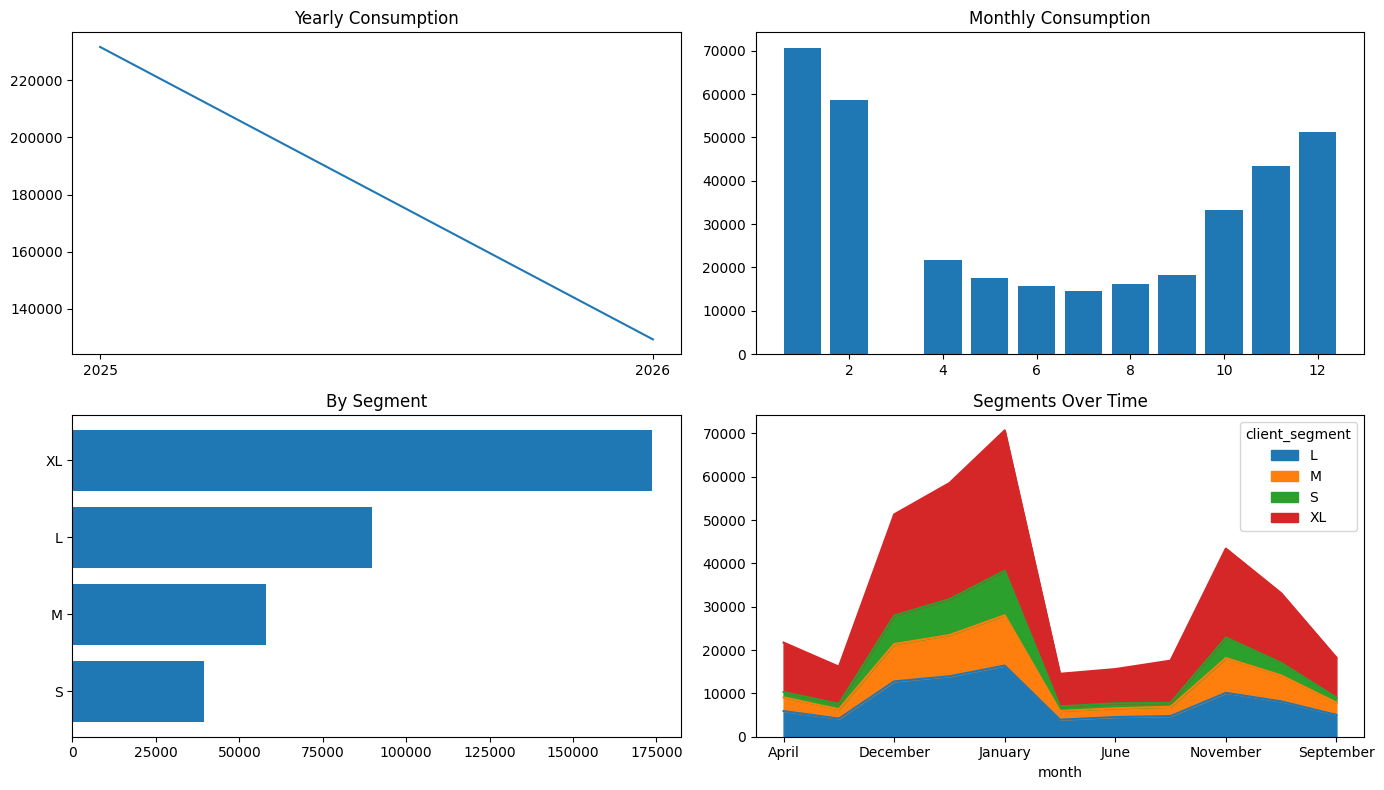

In [89]:

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# Yearly trend
axes[0, 0].plot(consumption_per_year['year'].astype(str), consumption_per_year['total_consumption_kwh'])
axes[0, 0].set_title('Yearly Consumption')

# Monthly bars
axes[0, 1].bar(consumption_per_month['month'], consumption_per_month['total_consumption_kwh'])
axes[0, 1].set_title('Monthly Consumption')

# Segment comparison
axes[1, 0].barh(consumption_per_segment['client_segment'], consumption_per_segment['total_consumption_kwh'])
axes[1, 0].set_title('By Segment')

# Monthly segments (pivot for stacking)
pivot = monthly_segments.pivot(index='month', columns='client_segment', values='total_consumption_kwh')
pivot.plot(kind='area', stacked=True, ax=axes[1, 1])
axes[1, 1].set_title('Segments Over Time')

plt.tight_layout()
plt.show()

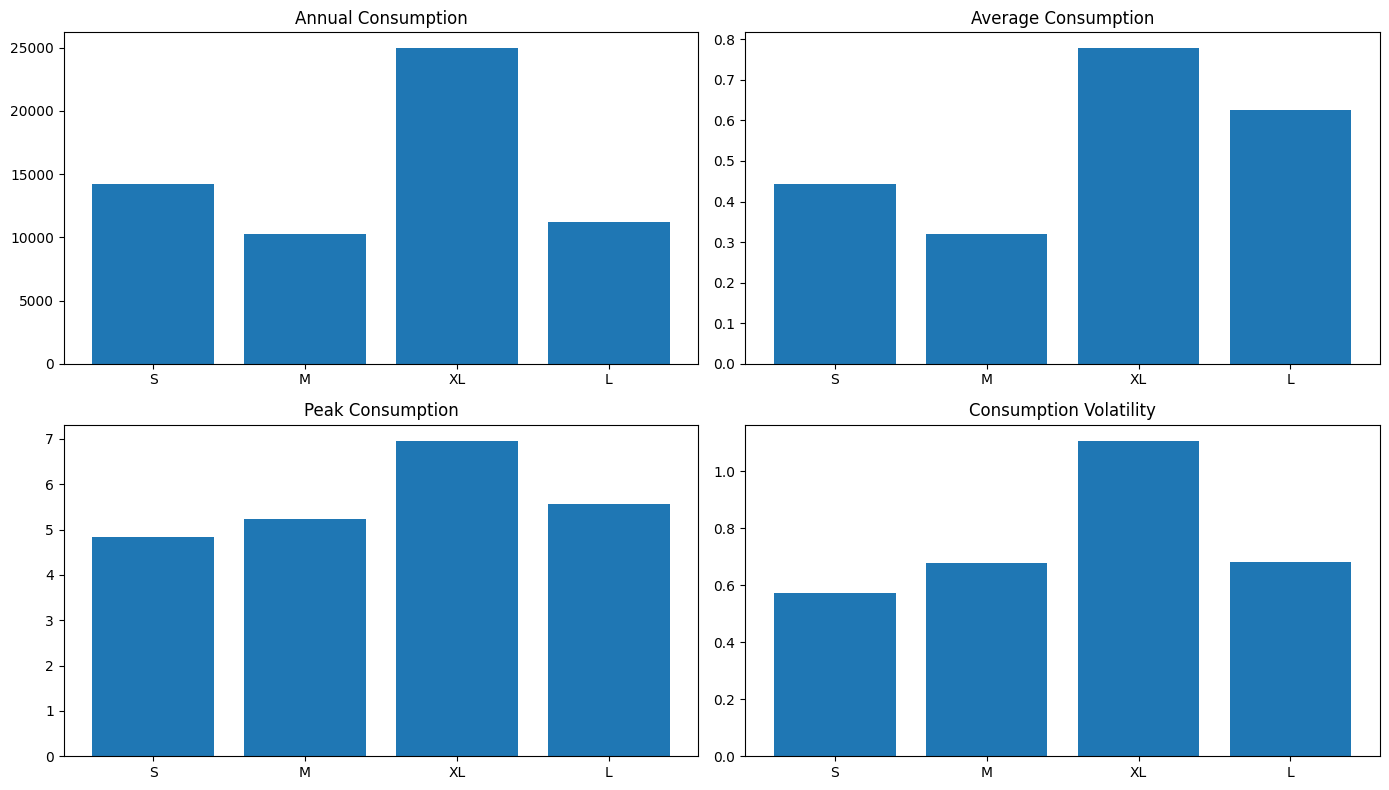

In [111]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

axes[0, 0].bar(consumption_stats['client_segment'], consumption_stats['annual_consumption'])
axes[0, 0].set_title('Annual Consumption')

axes[0, 1].bar(consumption_stats['client_segment'], consumption_stats['avg_consumption'])
axes[0, 1].set_title('Average Consumption')

axes[1, 0].bar(consumption_stats['client_segment'], consumption_stats['peak_consumption'])
axes[1, 0].set_title('Peak Consumption')

axes[1, 1].bar(consumption_stats['client_segment'], consumption_stats['consumption_volatility'])
axes[1, 1].set_title('Consumption Volatility')

plt.tight_layout()
plt.show()

In [110]:
print(type(consumption_stats))


<class 'pandas.DataFrame'>


In [90]:
consumption_df.head()


,household_id,timestamp,date,time,consumption_kwh,dayofweek,hour
0,s-1,2025-04-01 00:00:00,2025-04-01,1900-01-01 00:00:00,0.026,1,0
1,s-1,2025-04-01 00:15:00,2025-04-01,1900-01-01 00:15:00,0.063,1,0
2,s-1,2025-04-01 00:30:00,2025-04-01,1900-01-01 00:30:00,0.021,1,0
3,s-1,2025-04-01 00:45:00,2025-04-01,1900-01-01 00:45:00,0.028,1,0
4,s-1,2025-04-01 01:00:00,2025-04-01,1900-01-01 01:00:00,0.013,1,1


In [114]:
consumption_df_enriched = consumption_df.assign(
    client_segment=consumption_df['household_id'].str.split('-').str[0],
    month_name=pd.to_datetime(consumption_df['timestamp']).dt.strftime('%B'),
    day_of_week=pd.to_datetime(consumption_df['timestamp']).dt.day_name(),
    hour=pd.to_datetime(consumption_df['timestamp']).dt.hour,
    is_weekend=pd.to_datetime(consumption_df['timestamp']).dt.dayofweek >= 5,
    season=pd.to_datetime(consumption_df['timestamp']).dt.month.map({
        12: 'Winter', 1: 'Winter', 2: 'Winter',
        3: 'Spring', 4: 'Spring', 5: 'Spring',
        6: 'Summer', 7: 'Summer', 8: 'Summer',
        9: 'Fall', 10: 'Fall', 11: 'Fall'
    })
)

# Save as new file
consumption_df_enriched.to_csv('consumption_df_enriched.csv', index=False)


In [ ]:
consumption_df_enriched = consumption_df_enriched.drop(columns=['month'])

In [115]:
consumption_df_enriched.head()

,household_id,timestamp,date,time,consumption_kwh,dayofweek,hour,client_segment,month_name,day_of_week,is_weekend,season
0,s-1,2025-04-01 00:00:00,2025-04-01,1900-01-01 00:00:00,0.026,1,0,s,April,Tuesday,False,Spring
1,s-1,2025-04-01 00:15:00,2025-04-01,1900-01-01 00:15:00,0.063,1,0,s,April,Tuesday,False,Spring
2,s-1,2025-04-01 00:30:00,2025-04-01,1900-01-01 00:30:00,0.021,1,0,s,April,Tuesday,False,Spring
3,s-1,2025-04-01 00:45:00,2025-04-01,1900-01-01 00:45:00,0.028,1,0,s,April,Tuesday,False,Spring
4,s-1,2025-04-01 01:00:00,2025-04-01,1900-01-01 01:00:00,0.013,1,1,s,April,Tuesday,False,Spring
